In [ ]:
# ruimte voor uitwerking

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit

BOX_SIZE_0 = 10               # Hoogte en lengte startvolume
N = 40                       # Aantal deeltjes
V_0 = 1                      # Startsnelheid van deeltjes
RADIUS = 0.3                   # Straal van moleculen
DT = 0.1*RADIUS/V_0                       # Tijdstap om geen botsing te missen
V_PISTON_0 = 0.1 * V_0      # Startsnelheid van zuiger 
# (negatief betekent zowel links als rechts naar binnen gericht)

#your code/answer


In [ ]:
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    dx = p1.r[0]-p2.r[0]
    dy = p1.r[1]-p2.r[1]
    rr = p1.R + p2.R
    return  dx**2+dy**2 < rr**2 

def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

In [ ]:
box_height = BOX_SIZE_0     # hoogte van beheersvolume
box_left = -BOX_SIZE_0/2     # linkerkant van beheersvolume
box_length = BOX_SIZE_0     # rechterkant van beheersvolume
impulse_outward = 0.0       # totale stoot van deeltjes naar buiten gericht
pressure = 0.0              # druk in beheersvolume
v_piston = V_PISTON_0       # huidige snelheid van zuiger 
work = 0.0                  # arbeid uitgevoerd door gas

In [ ]:
def top_down_collision(particle: ParticleClass):
    """ botsingen met wanden onder en boven controleren en totale stoot bepalen """
    global impulse_outward, box_height
    if abs(particle.r[1]) + particle.R > box_height / 2:
        particle.r[1] = np.sign(particle.r[1]) * (box_height/2 - particle.R)
        impulse_outward += abs(particle.momentum[1]) * 2
        particle.v[1] *= -1
    
def left_right_collision(particle: ParticleClass):
    global impulse_outward, box_length, box_left
    # Left wall collision
    if particle.r[0] < box_left + particle.R:
        particle.r[0] = box_left + particle.R
        impulse_outward += abs(particle.momentum[0]) * 2
        particle.v[0] *= -1
    # Right wall collision
    elif particle.r[0] > box_left + box_length - particle.R:
        particle.r[0] = box_left + box_length - particle.R
        impulse_outward += abs(particle.momentum[0]) * 2
        particle.v[0] *= -1

In [ ]:
def create_particles(particles):
    """ Leegmaken en opnieuw aanmaken van deeltjes  in lijst """
    global box_length, box_height
    particles.clear()
    for _ in range(N):
        vx = np.random.uniform(-V_0, V_0)
        vy = np.random.choice([-1, 1]) * np.sqrt(V_0**2 - vx**2)        
        x = np.random.uniform(-box_length/2 + RADIUS, box_length/2 - RADIUS)
        y = np.random.uniform(-box_height/2 + RADIUS, box_height/2 - RADIUS)
        particles.append(ParticleClass(m=1.0, v=[vx, vy], r=[x, y], R=RADIUS))
    
def temperature(particles) -> float:
    # De oplossing van je vorige werkblad
    temp = 0.0 
    total_kin_energy = 0.0
    for p in particles:
        total_kin_energy += p.kin_energy
    total_kin_energy = total_kin_energy * 4.65e-26  * 500**2 # omzetten naar kg m2/s2
    temp = (2/2) * (total_kin_energy / (N * 1.380649e-23))
#your code/answer
    return temp
        
def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])

def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst en gemiddeld bepaling druk """
    global pressure, impulse_outward, box_height, box_length   # om pressure buiten de functie te kunnen gebruiken
    impulse_outward = 0.0
    for p in particles:
        left_right_collision(p)
        top_down_collision(p)    
    pressure = 0.95 * pressure + 0.05 * impulse_outward / ((2 * box_length + 2 * box_height) * DT) 

def take_time_step(particles):
    """ zet tijdstap voor een lijst deeltjes en verwerk alle botsingen onderling en met wanden """
    global box_left, v_piston, kinetic_energy
    box_left += v_piston * DT
    kinetic_energy = 0.0
    for p in particles:
        p.update_position()
        kinetic_energy += p.kin_energy
    handle_walls(particles)  
    handle_collisions(particles)


In [ ]:
# Deel van de animated simulatie
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-BOX_SIZE_0/2, 1.5*BOX_SIZE_0/2)
ax.set_ylim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
ax.set_aspect('equal')
dot, = ax.plot([], [], 'ro', ms=14)

def init():
    dot.set_data([], [])
    return dot,

# we kiezen het aantal datapunten zodat het volume tot 1/3 van het begin volume reduceert
num_steps = round(BOX_SIZE_0 / (V_PISTON_0 * DT))

particles = []

box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes     

def update(frame):
    take_time_step(particles)
    dot.set_data([p.r[0] for p in particles], [p.r[1] for p in particles])
    return dot,

ani = FuncAnimation(fig, update, frames=int(num_steps/2), init_func=init, blit=True, interval=50)
HTML(ani.to_jshtml())

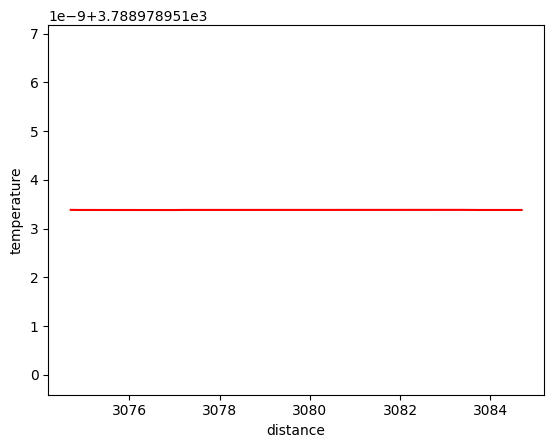

In [48]:
particles = []
pressure = 0.0
work = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 

num_steps = round(BOX_SIZE_0 / (V_PISTON_0 * DT))
box_distances = []
temps = []

# breid deze code uit met jouw antwoord
for i in range(num_steps):
    take_time_step(particles)
    box_distances.append(box_left + 0.5 * BOX_SIZE_0)
    temps.append(temperature(particles))

plt.figure()
plt.xlabel('distance')
plt.ylabel('temperature')
plt.plot(box_distances, temps, '-r')
plt.show()
